# Tabular data exploration

Terminology: 
- "sample" = record = observation
- "columns" = features = variables = attributes

Inspect the data 
- peculiarities from data collection or processing (truncation)


Histograms
- not much age > 70 -> hours per week > 0 filtered out (working-age population)


Imbalance
- in target -> need to account for when evaluating (predicting the rare class is more difficult)
- male/female imbalance - model may learn better for the majority group, leading to outsized errors on the minority group


Careful with
- class imbalance in target data -> needs special treatment. for instance, the model may learn to predict the majority class just because it's the majority. 
- class imbalance in predictor (sex) -> model parameters may be dominated by majority group, leading to larger prediction errors for minority groups




To get the data 
```bash
wget https://zenodo.org/records/14851649/files/datasets.zip 
unzip datasets.zip
```

In [1]:
import pandas as pd

In [2]:
#?pd.crosstab

In [3]:
!ls ../datasets

adult-census.csv	       cps_85_wages.csv
adult-census-numeric-all.csv   financial-data
adult-census-numeric.csv       house_prices.csv
adult-census-numeric-test.csv  penguins_classification.csv
ames_housing_no_missing.csv    penguins.csv
bike_rides.csv		       penguins_regression.csv
blood_transfusion.csv	       README.md


## Exercise M1.01

In [4]:
penguins = pd.read_csv("../datasets/penguins_classification.csv")

In [5]:
penguins.head()

,Culmen Length (mm),Culmen Depth (mm),Species
0,39.1,18.7,Adelie
1,39.5,17.4,Adelie
2,40.3,18.0,Adelie
3,36.7,19.3,Adelie
4,39.3,20.6,Adelie


- numerical: culmen length/depth
- categorical: species

In [6]:
penguins["Species"].value_counts()

Species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

In [7]:
numerical_columns = penguins.columns[:2]
numerical_columns

Index(['Culmen Length (mm)', 'Culmen Depth (mm)'], dtype='str')

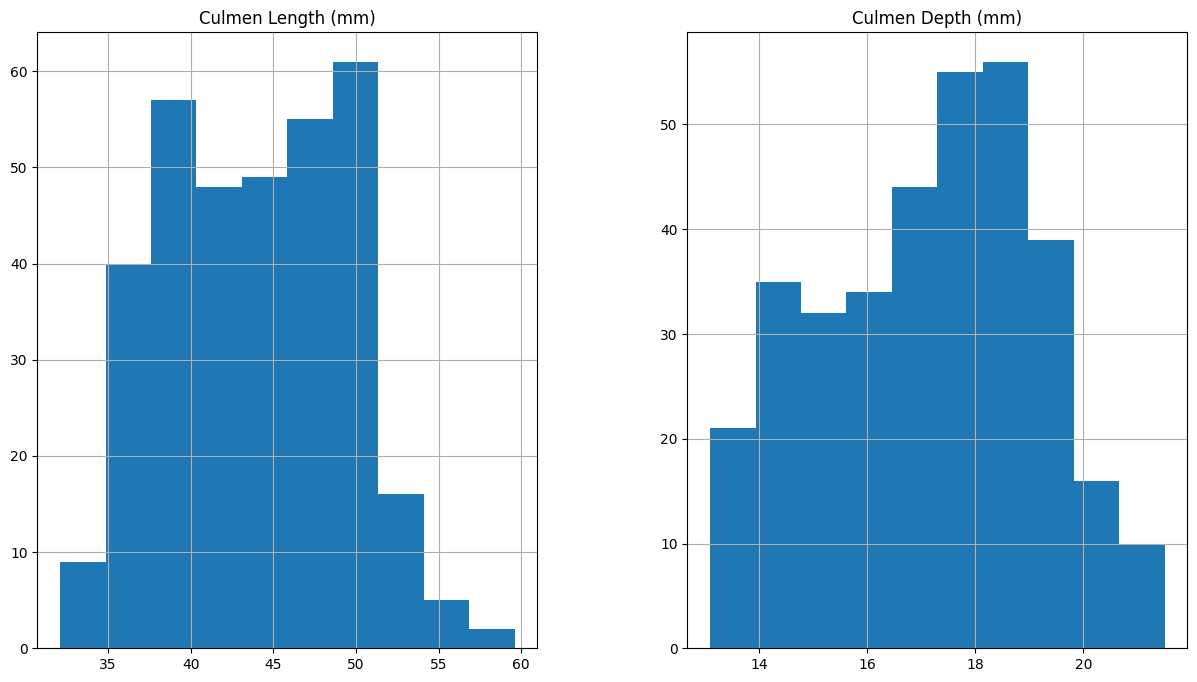

In [8]:
_ = penguins[numerical_columns].hist(figsize=(40,8), layout=(1,5))

In [9]:
import seaborn as sns

In [10]:
penguins.head()

,Culmen Length (mm),Culmen Depth (mm),Species
0,39.1,18.7,Adelie
1,39.5,17.4,Adelie
2,40.3,18.0,Adelie
3,36.7,19.3,Adelie
4,39.3,20.6,Adelie


In [11]:
target_column = penguins["Species"]

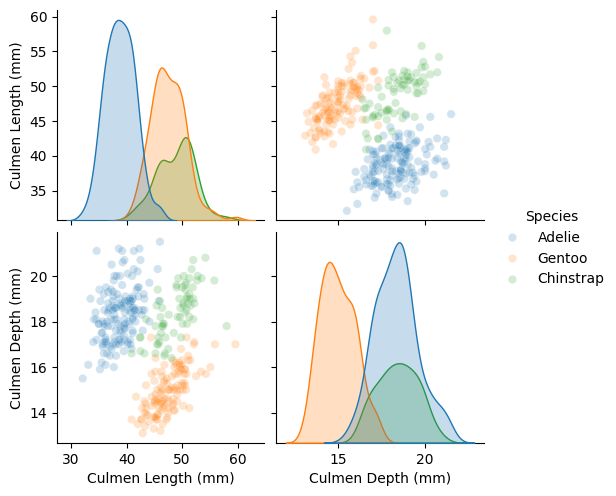

In [12]:
sns.pairplot(
    data=penguins,
    vars=numerical_columns,
    hue="Species",
    plot_kws={"alpha": 0.2},
)
    

# Preprocessing numerical features

### Goal
- Previously oversimplified -- only numerical features, train-test split not automatic

Now
- automatically separate train-test splits
- train & evaluate more complex scikit-learn model
- show an example of preprocessing
- use a scikit-learn *pipeline* to chain processing and evaluation

In [13]:
# load the entire dataset
import pandas as pd 
adult_census = pd.read_csv("../datasets/adult-census.csv")

In [14]:
# drop duplicated column as stated in the slides
adult_census = adult_census.drop(columns="education-num")


In [15]:
data = adult_census.drop(columns="class") # commonly named X in sklearn
target = adult_census["class"] # commonly named y in sklearn

Identifying numerical data
- numerical data are measurable -- age, number of hours worked
- they are represented by numbers -- but not all numerical columns represent numerical data!


In [16]:
data[["age", "hours-per-week", "sex", "race"]].dtypes

age               int64
hours-per-week    int64
sex                 str
race                str
dtype: object

In [17]:
data[["age", "hours-per-week", "sex", "race"]].head()

,age,hours-per-week,sex,race
0,25,40,Male,Black
1,38,50,Male,White
2,28,40,Male,White
3,44,40,Male,Black
4,18,30,Female,White


In [18]:
# depending on your version of pandas, you may see "object" instead of "str" (pandas < 3.0)

In [19]:
# let's select only the numerical columns now
numerical_columns = ["age", "capital-gain", "capital-loss", "hours-per-week"]
data[numerical_columns].head()

,age,capital-gain,capital-loss,hours-per-week
0,25,0,0,40
1,38,0,0,50
2,28,0,0,40
3,44,7688,0,40
4,18,0,0,30


In [20]:
# create a new dataframe for this subset of columns
data_numeric = data[numerical_columns]

### Train-test split the dataset
- we can do this automatically
- it is useful for building bigger pipelines with sklearn

In [43]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data_numeric, target, random_state=42, test_size=0.25
)
# random_state -> deterministic results (same samples)
# test_size -> 1/4 of data are in test set

### Model fitting without pre-processing
- we'll use logistic regression instead of k-nearest neighbors
- it's a kind of linear model; more widely used than KNN

example rule: if `0.1 * age + 3.3 * hours-per-week - 15.1 > 0`, predict `high-income`

In [44]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [45]:
# use it as before
model.fit(data_train, target_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [47]:
# use the score method to see how well the model generalizes
accuracy = model.score(data_test, target_test)
print(f"Accuracy of logistic regression: {accuracy:.3f}")

Accuracy of logistic regression: 0.807


### Model fitting with pre-processing
- we'll use sklearn utilities to standardize the numerical features

In [49]:
data_train.describe()

,age,capital-gain,capital-loss,hours-per-week
count,36631.000000,36631.000000,36631.000000,36631.000000
mean,38.642352,1087.077721,89.665311,40.431247
std,13.725748,7522.692939,407.110175,12.423952
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


Some algorithms rely on data being normalized, so this is a good thing to do in most cases
- KNN: relies distance between pairs -> all distances should be in same units
- can also speed up model solving
- decision trees: less relevant, but does not hurt

**We'll use the `StandardScaler`**: shifts and scales each feature individually to have 0 mean and std.
This transformer is also an estimator and has `fit` and a `transform` method.

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(data_train)

StandardScaler()

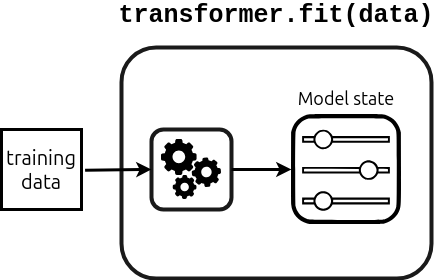

In [52]:
# we can look at the computed statistics
scaler.mean_

array([  38.64235211, 1087.07772106,   89.6653108 ,   40.43124676])

In [55]:
scaler.scale_ # the standard deviation

array([  13.72556083, 7522.59025606,  407.10461772,   12.42378265])

In [56]:
# now we can transform the data
data_train_scaled = scaler.transform(data_train)
data_train_scaled

array([[ 0.17177061, -0.14450843,  5.71188483, -2.28845333],
       [ 0.02605707, -0.14450843, -0.22025127, -0.27618374],
       [-0.33822677, -0.14450843, -0.22025127,  0.77019645],
       ...,
       [-0.77536738, -0.14450843, -0.22025127, -0.03471139],
       [ 0.53605445, -0.14450843, -0.22025127, -0.03471139],
       [ 1.48319243, -0.14450843, -0.22025127, -2.69090725]],
      shape=(36631, 4))

#### Methods of the scaler
- `transform`: has state (parameters); given data, transforms them with the parameters
- `fit_transform`: calls `fit` on the data and then transforms them as well

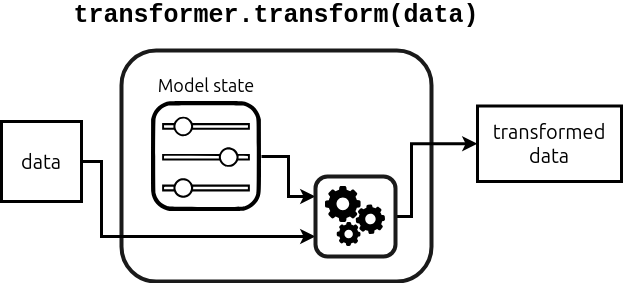

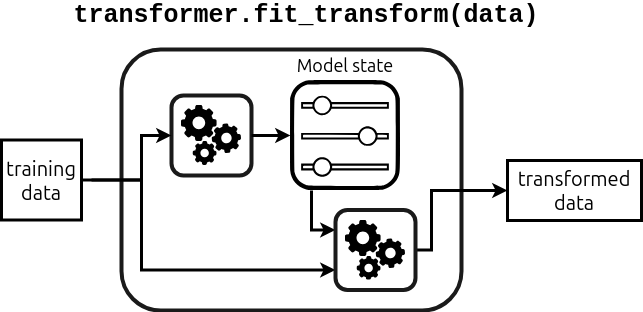

In [57]:
data_train_scaled = scaler.fit_transform(data_train)
data_train_scaled

array([[ 0.17177061, -0.14450843,  5.71188483, -2.28845333],
       [ 0.02605707, -0.14450843, -0.22025127, -0.27618374],
       [-0.33822677, -0.14450843, -0.22025127,  0.77019645],
       ...,
       [-0.77536738, -0.14450843, -0.22025127, -0.03471139],
       [ 0.53605445, -0.14450843, -0.22025127, -0.03471139],
       [ 1.48319243, -0.14450843, -0.22025127, -2.69090725]],
      shape=(36631, 4))

In [63]:
data_train_scaled[:, 0].std()

np.float64(1.0)

In [64]:
data_train_scaled[:, 1].std()

np.float64(0.9999999999999998)

### Using a Pipeline
- chains together operations; can be used in the same way as a classifier or regressor

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression())
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio 

In [67]:
# model.named_steps # omit?

In [68]:
model.fit(data_train, target_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","[' <=50K',' >50K']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['age','capital-gain','capital-loss','hours-per-week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [70]:
predicted_target = model.predict(data_test)
predicted_target[:5]

array([' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K'], dtype=object)

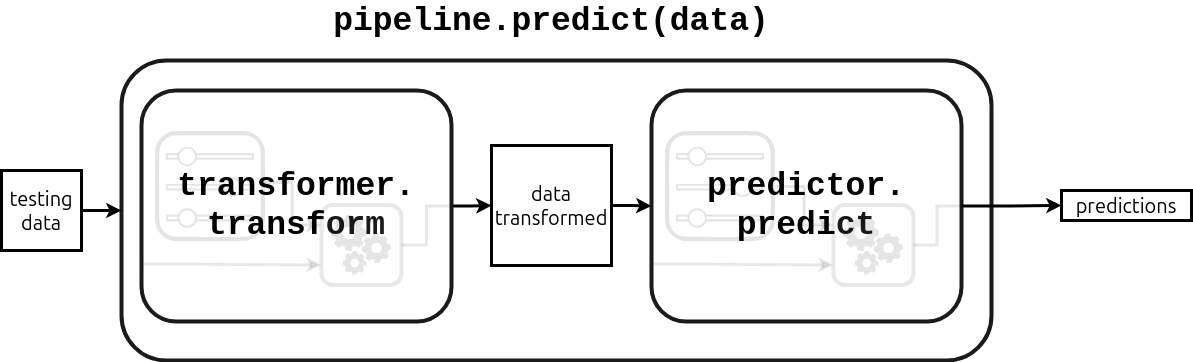

Notes
- no need to call `fit` neither on the transformer


In [72]:
# Check performance of the full pipeline with `score`
score = model.score(data_test, target_test)
print(f"The accuracy of using a Pipeline is {score:.3f}")

The accuracy of using a Pipeline is 0.807


### Summary
- using the scaler did not affect the score of the logistic regression, but made it faster (believe us)
- we saw how we can automate machine learning pipelines with train/test splits, preprocessing functions, and pipelines to chain them together
- we predicted around 8 out of 10 cases correctly -> but how good is this really? -- see exercise

## Exercise M1.03

In [74]:
adult_census = pd.read_csv("../datasets/adult-census.csv")
target_name = "class"
target = adult_census[target_name]
data = adult_census.drop(columns=target_name)

In [75]:
numerical_columns = ["age", "capital-gain", "capital-loss", "hours-per-week"]

data_numeric = data[numerical_columns]

In [76]:
from sklearn.model_selection import train_test_split

In [78]:
data_train, data_test, target_train, target_test = train_test_split(
    data_numeric, target, random_state=42, test_size=0.25
)

In [77]:
from sklearn.dummy import DummyClassifier

In [84]:
class_to_predict = " >50K"
high_revenue_classifier = DummyClassifier(
    strategy="constant", constant=class_to_predict
)
high_revenue_classifier.fit(data_train, target_train)
score = high_revenue_classifier.score(data_test, target_test)
print(score)

0.23396937187781508


In [86]:
class_to_predict = " <=50K"
low_revenue_classifier = DummyClassifier(
    strategy="constant", constant=class_to_predict
)
low_revenue_classifier.fit(data_train, target_train)
score = low_revenue_classifier.score(data_test, target_test)
print(score)

0.7660306281221849


In [87]:
# this is driven by the fact that most people are in low-income class

In [89]:
(target_test == " <=50K").mean()

np.float64(0.7660306281221849)

In [93]:
# the default is to choose the "most_frequent" (omit in interest of time)

In [92]:
most_frequent_classifier = DummyClassifier(strategy="most_frequent")
most_frequent_classifier.fit(data_train, target_train)
score = most_frequent_classifier.score(data_test, target_test)
print(score)

0.7660306281221849


**Conclusion**: using the logistic regressions does seem to learn someting

# Using numerical and categorical features together 
- Previously: treated numerical and categorical features separately
- Now: combine them

In [94]:
# load data as before
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census.csv")
# drop the duplicated column `"education-num"` as stated in the first notebook
adult_census = adult_census.drop(columns="education-num")

target_name = "class"
target = adult_census[target_name]

data = adult_census.drop(columns=[target_name])

In [95]:
# we use the `make_column_selector` function from sklearn
from sklearn.compose import make_column_selector as selector

In [97]:
# recall -- data.dtypes

In [106]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object) 

*Note*: replacing `object` with `str` should work too (for pandas >3.0)

In [103]:
numerical_columns = numerical_columns_selector(data)
categorical_columns = categorical_columns_selector(data)

In [111]:
# It's good to verify to avoid mistakes
numerical_columns

['age', 'capital-gain', 'capital-loss', 'hours-per-week']

In [112]:
categorical_columns

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country']

### Dispatch to specific processor
- `ColumnTransformer` class sends sepeicifc columns to specific transformer -> we can use both numerical and categorical columns
- for categorical columns, we use one-hot encoding
- for numerical features, we use standard scaler

In [113]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()

In [115]:
from sklearn.compose import make_column_transformer
preprocessor = make_column_transformer(
    (categorical_preprocessor, categorical_columns),
    (numerical_preprocessor, numerical_columns),
)

This figure illustrates what the `ColumnTransformer` does:

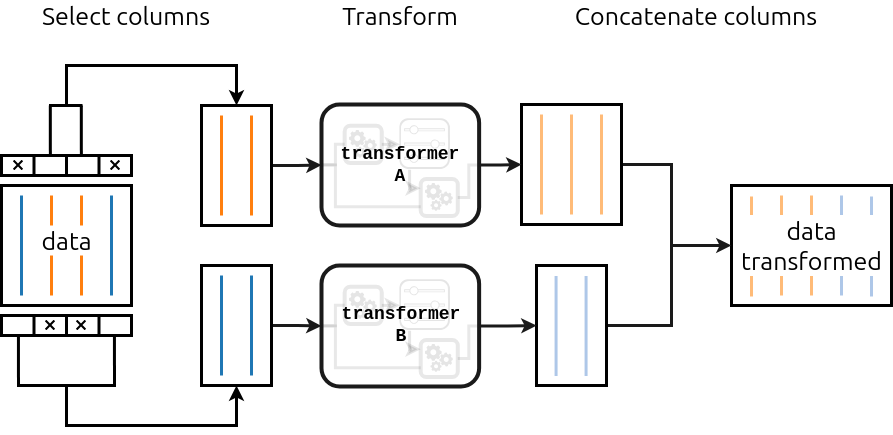

Specifically,
- it splits columns based on column names or indices provided
- transforms each subset by internally calling `fit_transform` or `transform`
- concatenates datasets into  single dataset

**The ColumnTransformer can be used as any other transformer (StandardScaler etc) in a pipeline**

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

In [117]:
model = make_pipeline(preprocessor, LogisticRegression(max_iter=500))
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold spa

We can still use the same methods as before - `fit`, `predict`, `score`

In [118]:
from sklearn.model_selection import train_test_split

In [120]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=42
) # We'd ideally use the cross-validation here; we keep it out here for simplicity/didactic purposes

In [121]:
_ = model.fit(data_train, target_train)

In [122]:
model.score(data_test, target_test)

0.8575055278028008

### Wrap-up

We learned
- how to create a scikit-learn predictive model
- about the sklearn API to train and test a predictive model
- to process numerical data and categorical data; separately or together with the `ColumnTransformer`

# Bias-variance trade-off
- bias/variance = statistical terms
- underfitting/overfitting = ML terms

### Resampling the training set
- we do not have unlimited amount of data
- we can see our training set as a small random subset of all possible observations
(re-sampling training set = test set!)

**what would happen to the model if we re-sampled the training set?**

### Overfit: variance
- red `f` = estimated on small sample. degree 9 polynomial
- dashed `f*` = ground truth
- different sample -> different function.
- on average, each models make systematic error

**variance of the estimated model** -> large dependency on small variation in the training set

### Underfit: bias
- dashed `f*` = ground truth
- blue `f` = estimated on small sample (1-degree polynomial)
- changing the sample does not change the function very much. slope very similar, errors also very close to each other
- models make same kind of errors: bias that moves models away from the center

**The trade-off: it's rare to have low bias and low variance**
- we can have "on average" low bias, but because of sampling noise, we can high variance
- we can have low variance, but then chances are that our predictions are scattered not around the true values, leading to bias

### Take-home messages
- high bias = overfitting = systematic prediction errors. "model is mis-specified"
- high variance = overfitting = prediction errors without obvious structure. "model is unstable"

*Note, bias can also come from the choice of the model family, and not just the flexibility of the model*
